<a href="https://colab.research.google.com/github/sprice134/PromptMoE/blob/master/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !git clone https://github.com/sprice134/PromptMoE.git
    %cd /content/PromptMoE/segment-anything
    !pip install -e .
    %cd /content/PromptMoE
    !pip install matplotlib transformers scikit-image opencv-python timm pandas
    !pip install torch torchvision
    !pip install --upgrade diffusers[torch]
    !mkdir checkpoints/
    !wget -O checkpoints/sam_vit_h.pth \
      https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

Cloning into 'PromptMoE'...
remote: Enumerating objects: 2207, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 2207 (delta 7), reused 21 (delta 5), pack-reused 2177 (from 4)
Receiving objects: 100% (2207/2207), 147.38 MiB | 6.04 MiB/s, done.
Resolving deltas: 100% (1253/1253), done.
Updating files: 100% (2293/2293), done.
/content/PromptMoE/segment-anything
Obtaining file:///content/PromptMoE/segment-anything
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for segment_anything (pyproject.toml) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-0.editable-py3-none-any.whl size=7065 sha256=06de5b4c45be279698dd3af8a010cf7e0e7680ec85860d2b84d43e27c9484ab7
  Stored in directory: /tmp/pip-ephem-wheel-cache-5xq_6jb8/wheels/0

# Imports and Setup

In [2]:
import os
import sys
import importlib.util

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO_ROOT = "/content/PromptMoE"
sys.path.insert(0, os.path.join(REPO_ROOT, "segment-anything"))
from segment_anything import SamPredictor, SamAutomaticMaskGenerator
from segment_anything.utils.transforms import ResizeLongestSide


PROMPTMOE_PATH = os.path.join(REPO_ROOT, "PromptMoE.py")

CHECKPOINT_PATH = os.path.join(REPO_ROOT, "checkpoints", "sam_vit_h.pth")
ROUTER_CKPT    = os.path.join(REPO_ROOT, "DES_ROUTER.pt")

IMAGE_PATH = os.path.join(REPO_ROOT, "figures", "demo", "giraffeRaw.jpg")
MASK_PATH  = os.path.join(REPO_ROOT, "figures", "demo", "giraffePredMask.png")
SAVE_PATH  = os.path.join(REPO_ROOT, "figures", "demo", "giraffeRefined.png")

MARIGOLD_CHECKPOINT = None  # set to a valid checkpoint if you want depth

DEVICE_STR = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(DEVICE_STR)
print("Using device:", device)


Using device: cpu


# Load SAM, Router and Marigold (Optional)

In [3]:
spec = importlib.util.spec_from_file_location("PromptMoE", PROMPTMOE_PATH)
PromptMoE = importlib.util.module_from_spec(spec)
spec.loader.exec_module(PromptMoE)  # type: ignore

sam_model = PromptMoE.load_sam(CHECKPOINT_PATH, device, model_type="vit_h")
sam_model.eval()

predictor = SamPredictor(sam_model)
resize_tf = ResizeLongestSide(sam_model.image_encoder.img_size)
mask_gen = SamAutomaticMaskGenerator(model=sam_model)

router, router_cfg = PromptMoE.load_router(ROUTER_CKPT, device)
if router is None or router_cfg is None:
    raise RuntimeError(f"Router or router_cfg failed to load from {ROUTER_CKPT}")

if MARIGOLD_CHECKPOINT is not None:
    mg = PromptMoE.MarigoldRunner(MARIGOLD_CHECKPOINT, device, half=False)
else:
    mg = None


[Router] Loaded PairRouter; d_ctx=518, E=10


# Load Image and Coarse Mask

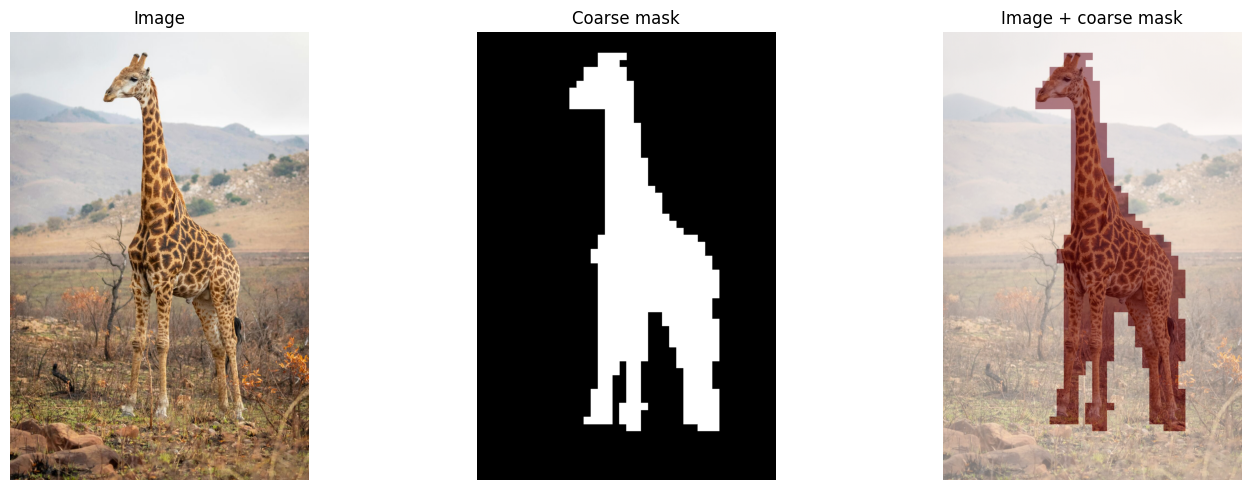

In [4]:
bgr = cv2.imread(IMAGE_PATH, cv2.IMREAD_COLOR)
if bgr is None:
    raise FileNotFoundError(f"Could not read image at {IMAGE_PATH}")
image_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

mask_raw = cv2.imread(MASK_PATH, cv2.IMREAD_GRAYSCALE)
if mask_raw is None:
    raise FileNotFoundError(f"Could not read mask at {MASK_PATH}")

coarse_mask_255 = (mask_raw > 0).astype(np.uint8) * 255

images_rgb = [image_rgb]
masks_255 = [coarse_mask_255]
image_ids = ["giraffe"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_rgb)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(coarse_mask_255, cmap="gray")
axes[1].set_title("Coarse mask")
axes[1].axis("off")

axes[2].imshow(image_rgb)
axes[2].imshow(coarse_mask_255, cmap="Reds", alpha=0.5)
axes[2].set_title("Image + coarse mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()


# Refine Mask

Refining masks: 100%|██████████| 1/1 [00:32<00:00, 32.05s/it]


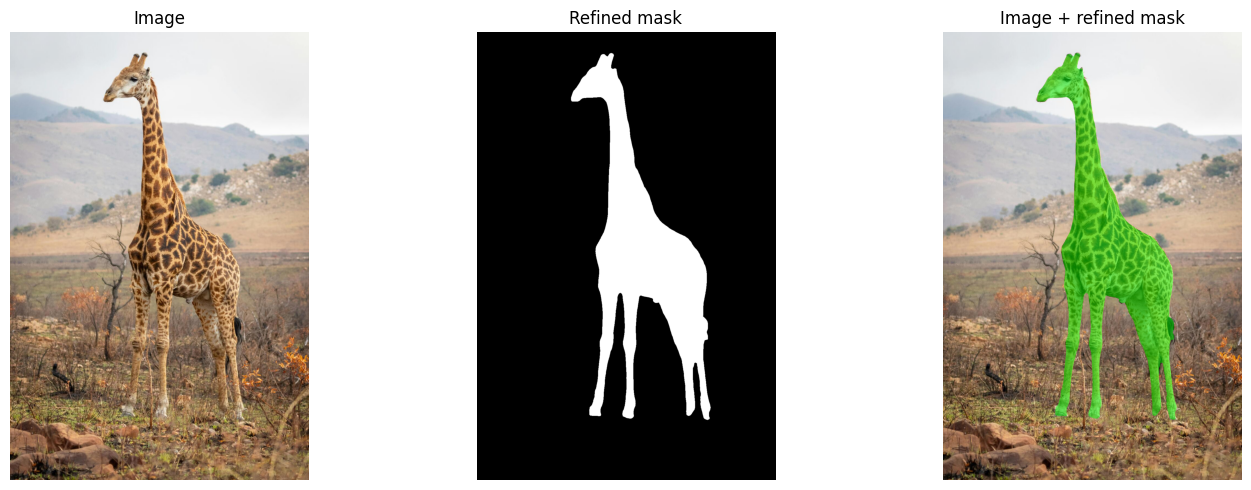

In [5]:
depth_cfg = dict(
    denoise=None,
    proc_res=None,
    ens=1,
    seed=None,
)

refined_masks = PromptMoE.refine_masks_from_arrays(
    images_rgb=images_rgb,
    coarse_masks_255=masks_255,
    sam_model=sam_model,
    predictor=predictor,
    device=device,
    router=router,
    router_cfg=router_cfg,
    mg=mg,
    beta=1.4,
    point_map="moe",
    k_points=5,
    suppression_frac=0.05,
    iters=10,
    use_point=True,
    use_box=True,
    use_mask=True,
    add_neg=True,
    margin=0.0,
    gamma=4.0,
    strength=30,
    router_topk=2,
    depth_cfg=depth_cfg,
    resize_tf=resize_tf,
    mask_gen=mask_gen,
    manual_weights_str=None,
    log_points=False,
    light_mode=True,
    use_samhq=False,
    save_dir=None,
    image_ids=image_ids,
)

refined_255 = refined_masks[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_rgb)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(refined_255, cmap="gray")
axes[1].set_title("Refined mask")
axes[1].axis("off")

mask_bool = refined_255 > 0
h, w = refined_255.shape
overlay = np.zeros((h, w, 4), dtype=float)
overlay[..., 1] = 1.0
overlay[..., 3] = mask_bool * 0.5

axes[2].imshow(image_rgb)
axes[2].imshow(overlay)
axes[2].set_title("Image + refined mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()


# Save Refined Mask

In [6]:
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
ok = cv2.imwrite(SAVE_PATH, refined_255)
if not ok:
    raise RuntimeError(f"Failed to write refined mask to {SAVE_PATH}")

print(f"Refined mask saved to {SAVE_PATH}")


Refined mask saved to /content/PromptMoE/figures/demo/giraffeRefined.png
